In [1]:
import pandas as pd
import optuna
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import shap
import wandb
from Optune_simulation_env import get_best_params, walk_forward_predict_test
from utils import load_data
from scipy.stats import ttest_rel

c:\Users\local_user\anaconda3\envs\EnergyPrices\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
N_TRIALS = 30
FINAL_TEST_DAYS = 30
OPTUNA_VAL_DAYS = 30
N_Optuna_Runs = 17
COUNTRY = "PL"

In [3]:
real_ds = load_data("real", COUNTRY)
synt_ds_lgbm = load_data("lgbm", COUNTRY)
synt_ds_spline = load_data("spline", COUNTRY)
synt_ds_intra = load_data("intra", COUNTRY)

In [4]:
def features():
    STATE_LAGS = [1, 4, 8, 24, 96, 192, 672]   # 15m, 1h, 2h, 6h, 1d, 2d, 1w
    STATE_ROLL_WINS = [24, 96, 672]            # rolling windows on past y (6h, 1d, 1w)
    
    # Feature columns

    STATE_FEATURES = (
        ["last_y"]
        + [f"lag_{L}_t0" for L in STATE_LAGS]
        + ["ramp_1h_t0", "ramp_6h_t0", "ramp_1d_t0"]
        + [f"roll_mean_{w}_t0" for w in STATE_ROLL_WINS]
        + [f"roll_std_{w}_t0" for w in STATE_ROLL_WINS]
    )

    HORIZON_FEATURES = [
        "h", "q_in_hour_target", "qod_target", "hod_target", "dow_target", "month_target", "is_weekend_target",
        "load_fc_target", "load_ramp_1h_target", "load_ramp_6h_target", "renewables_solar_fc","renewables_wind_fc",
        "load_day_mean", "load_day_max", "load_day_min", "q_in_hour_sin", "q_in_hour_cos", "qod_sin", "qod_cos", "hod_sin", "hod_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"
    ]

    WEIGHT_FEATURES = [
        'daily_weight_lag_1d',
        'daily_weight_lag_2d', 'daily_weight_lag_1w', 'hour_weight_lag_1d',
        'hour_weight_lag_2d', 'hour_weight_lag_1w', 'daily_avg_weight_lag_1d',
        'daily_avg_weight_lag_2d', 'daily_avg_weight_lag_1w',
        'hour_avg_weight_lag_1d', 'hour_avg_weight_lag_2d',
        'hour_avg_weight_lag_1w'
    ]

    FEATURE_COLS = STATE_FEATURES + HORIZON_FEATURES + WEIGHT_FEATURES

    return FEATURE_COLS

In [5]:
def run_optuna_once(ds: pd.DataFrame, model: str, synth_type :str, seed: int):
    np.random.seed(seed)
    #wandb.init(project="EnergyPrices_t_test", name=f"{model}_{synth_type}_seed_{seed}", reinit=True)

    FEATURES = features()
    all_days = np.array(sorted(ds["day"].unique()))
    final_test_days = all_days[-FINAL_TEST_DAYS:]
    tune_days = all_days[:-FINAL_TEST_DAYS]

    optuna_val_days = tune_days[-OPTUNA_VAL_DAYS:]
    optuna_train_days_pool = all_days

    study = get_best_params(
        ds=ds,
        train_days_pool=optuna_train_days_pool,
        val_days=optuna_val_days,
        n_trials=N_TRIALS,
        FEATURE_COLS=FEATURES,
        model_type=model,
        seed=seed,  # IMPORTANT if supported
        study_name="HUPX_CatBoost"
    )

    best_params = study.best_params

    test_res = walk_forward_predict_test(
        ds=ds,
        best_params=best_params,
        train_days_pool=optuna_train_days_pool,
        test_days=final_test_days,
        feature_cols=FEATURES,
        model_type=model
    )

    y_true = test_res["y_true"]
    y_pred = test_res["y_pred"]

    rmse = root_mean_squared_error(y_true=y_true, y_pred=y_pred)

    #wandb.log({
    #     "final_mae": test_res["mae"],
    #     "final_rmse": rmse
    # })
    # wandb.finish()


    return {
        "mae": test_res["mae"],
        "rmse": rmse
    }

In [6]:
from catboost import CatBoostRegressor
def fit_final_model_before_test(
    ds,
    best_params: dict,
    train_days_pool: np.ndarray,
    first_test_day,
    feature_cols,
    target_col="y_target",
    day_col="day",
    synth_col="is_synthetic",
    seed=0
):
    np.random.seed(seed)
    ds_train_pool = ds[ds[day_col].isin(train_days_pool)].copy()
    train_slice = ds_train_pool[ds_train_pool[day_col] < first_test_day].copy()
    if train_slice.empty:
        raise RuntimeError("Training slice is empty before first_test_day.")

    synth_weight = best_params["synth_weight"]
    w = np.where(train_slice[synth_col].values == 1, synth_weight, 1.0).astype(float)

    params = {
                "depth" : best_params["depth"],
                "iterations" : best_params["iterations"],
                "l2_leaf_reg" : best_params["l2_leaf_reg"],
                "learning_rate" : best_params['learning_rate'],
                "objective": "RMSE",
                "random_state": 42,
                "silent" : True,
                "task_type" : "GPU",
                "boosting_type":'Plain',
            }

    model = CatBoostRegressor(**params)

    model.fit(train_slice[feature_cols], train_slice[target_col], sample_weight=w)
    return model

In [7]:
results_real_rmse = []
results_synth_lgbm_rmse = []
results_synth_spline_rmse = []
results_synth_intra_rmse = []
results_real_mae = []
results_synth_lgbm_mae = []
results_synth_spline_mae = []
results_synth_intra_mae = []

In [24]:
results_real_mae = [21.682813161356925, 24.76246551176497, 27.53921366776674, 19.489969533334992, 26.78388716046197, 20.44127342188364, 20.738266454409956, 17.698735227171348, 28.342470580146223, 23.072787057060637, 19.29406683617109, 24.476688729823017, 20.278838877956773, 21.035798226297082, 22.17621042057746]
results_synth_lgbm_mae = [20.11183348072083, 20.398475457067455, 21.03305164588943, 19.547840431199997, 21.223221447602988, 20.071455788722353, 22.097848499954157, 20.803934446139095, 20.685694686410994, 20.51425900577249, 21.90056963944867, 21.406700325414658, 21.27867437927311, 20.118091643160096, 21.27872997786026]
results_synth_spline_mae = [20.767520069935436, 20.077446456188564, 20.415957191921247, 20.419912177715535, 21.367064375346466, 19.97951911901881, 19.711195454574764, 20.31105196511956, 19.88435884862864, 20.984505374755752, 21.827663594796952, 19.894267835008268, 20.46191957629258, 20.139727063200297, 21.367768338590057]
results_synth_intra_mae = [21.052185768957468, 20.662450125758067, 21.01132431062579, 22.80008241944726, 21.614742853897507, 20.28349883162218, 19.973494116051192, 20.831482115700705, 20.220226671822218, 20.963950943579846, 22.189861038826898, 19.811944137765835, 20.30437822352907, 21.874699783014005, 20.36179357304729]

In [ ]:

#for i in range(N_Optuna_Runs):
for i in range(N_Optuna_Runs):
    print(f"Run {i}")

    res_real = run_optuna_once(real_ds, "catboost", "real",  seed=i)
    res_synth_lgbm = run_optuna_once(synt_ds_lgbm, "catboost","lightgbm", seed=i)
    res_synth_spline = run_optuna_once(synt_ds_spline, "catboost","spliine", seed=i)
    res_synth_intra = run_optuna_once(synt_ds_intra, "catboost","intra", seed=i)

    results_real_rmse.append(res_real["rmse"])
    results_synth_lgbm_rmse.append(res_synth_lgbm["rmse"])
    results_synth_spline_rmse.append(res_synth_spline["rmse"])
    results_synth_intra_rmse.append(res_synth_intra["rmse"])
    
    results_real_mae.append(res_real["mae"])
    results_synth_lgbm_mae.append(res_synth_lgbm["mae"])
    results_synth_spline_mae.append(res_synth_spline["mae"])
    results_synth_intra_mae.append(res_synth_intra["mae"])

[I 2026-04-18 17:28:43,443] A new study created in memory with name: HUPX_CatBoost


Run 0


[I 2026-04-18 17:28:49,079] Trial 0 finished with value: 20.90511632501434 and parameters: {'synth_weight': 0.7314410514212307, 'retrain_every': 8, 'depth': 7, 'learning_rate': 0.0431171005868549, 'iterations': 269, 'l2_leaf_reg': 7}. Best is trial 0 with value: 20.90511632501434.
[I 2026-04-18 17:28:57,518] Trial 1 finished with value: 19.68555470964086 and parameters: {'synth_weight': 0.6771687072426534, 'retrain_every': 9, 'depth': 8, 'learning_rate': 0.014135935551752304, 'iterations': 417, 'l2_leaf_reg': 6}. Best is trial 1 with value: 19.68555470964086.
[I 2026-04-18 17:28:58,931] Trial 2 finished with value: 27.874821230521622 and parameters: {'synth_weight': 0.7412564000282564, 'retrain_every': 10, 'depth': 4, 'learning_rate': 0.001825525480239901, 'iterations': 108, 'l2_leaf_reg': 9}. Best is trial 1 with value: 19.68555470964086.
[I 2026-04-18 17:29:04,811] Trial 3 finished with value: 22.109377863887474 and parameters: {'synth_weight': 0.8574691968694659, 'retrain_every': 9,

Best overall value: 18.396453328792926
Best overall params: {'synth_weight': 0.7872864278434154, 'retrain_every': 1, 'depth': 8, 'learning_rate': 0.025488302002381464, 'iterations': 236, 'l2_leaf_reg': 10}


[I 2026-04-18 17:36:12,743] A new study created in memory with name: HUPX_CatBoost
[I 2026-04-18 17:36:17,865] Trial 0 finished with value: 21.841801142186196 and parameters: {'synth_weight': 0.7314410514212307, 'retrain_every': 8, 'depth': 7, 'learning_rate': 0.0431171005868549, 'iterations': 269, 'l2_leaf_reg': 7}. Best is trial 0 with value: 21.841801142186196.
[I 2026-04-18 17:36:26,635] Trial 1 finished with value: 20.399187806564548 and parameters: {'synth_weight': 0.6771687072426534, 'retrain_every': 9, 'depth': 8, 'learning_rate': 0.014135935551752304, 'iterations': 417, 'l2_leaf_reg': 6}. Best is trial 1 with value: 20.399187806564548.
[I 2026-04-18 17:36:28,375] Trial 2 finished with value: 33.63682331360525 and parameters: {'synth_weight': 0.7412564000282564, 'retrain_every': 10, 'depth': 4, 'learning_rate': 0.001825525480239901, 'iterations': 108, 'l2_leaf_reg': 9}. Best is trial 1 with value: 20.399187806564548.
[I 2026-04-18 17:36:34,792] Trial 3 finished with value: 21.7

...

[I 2026-04-19 01:35:29,469] A new study created in memory with name: HUPX_CatBoost
[I 2026-04-19 01:35:39,791] Trial 0 finished with value: 21.10675107052735 and parameters: {'synth_weight': 0.9005121815756848, 'retrain_every': 2, 'depth': 4, 'learning_rate': 0.012151092816915616, 'iterations': 210, 'l2_leaf_reg': 6}. Best is trial 0 with value: 21.10675107052735.
[I 2026-04-19 01:35:49,910] Trial 1 finished with value: 21.105956336249502 and parameters: {'synth_weight': 0.6181028900441131, 'retrain_every': 4, 'depth': 4, 'learning_rate': 0.005619491797596132, 'iterations': 467, 'l2_leaf_reg': 3}. Best is trial 1 with value: 21.105956336249502.
[I 2026-04-19 01:35:54,063] Trial 2 finished with value: 21.569230415977326 and parameters: {'synth_weight': 0.8223210628245645, 'retrain_every': 9, 'depth': 8, 'learning_rate': 0.004282050136890366, 'iterations': 167, 'l2_leaf_reg': 1}. Best is trial 1 with value: 21.105956336249502.
[I 2026-04-19 01:36:14,876] Trial 3 finished with value: 20.0

Best overall value: 19.2534182987634
Best overall params: {'synth_weight': 0.7274959424102041, 'retrain_every': 2, 'depth': 7, 'learning_rate': 0.007557312843088673, 'iterations': 233, 'l2_leaf_reg': 9}


[I 2026-04-19 01:43:27,203] A new study created in memory with name: HUPX_CatBoost
[I 2026-04-19 01:43:37,428] Trial 0 finished with value: 20.546162980365303 and parameters: {'synth_weight': 0.9005121815756848, 'retrain_every': 2, 'depth': 4, 'learning_rate': 0.012151092816915616, 'iterations': 210, 'l2_leaf_reg': 6}. Best is trial 0 with value: 20.546162980365303.
[I 2026-04-19 01:43:47,436] Trial 1 finished with value: 21.118142550090347 and parameters: {'synth_weight': 0.6181028900441131, 'retrain_every': 4, 'depth': 4, 'learning_rate': 0.005619491797596132, 'iterations': 467, 'l2_leaf_reg': 3}. Best is trial 0 with value: 20.546162980365303.
[I 2026-04-19 01:43:51,904] Trial 2 finished with value: 21.923389005611185 and parameters: {'synth_weight': 0.8223210628245645, 'retrain_every': 9, 'depth': 8, 'learning_rate': 0.004282050136890366, 'iterations': 167, 'l2_leaf_reg': 1}. Best is trial 0 with value: 20.546162980365303.
[I 2026-04-19 01:44:12,570] Trial 3 finished with value: 19

Best overall value: 18.85195802045838
Best overall params: {'synth_weight': 0.5795339148649844, 'retrain_every': 5, 'depth': 8, 'learning_rate': 0.0815159559066739, 'iterations': 499, 'l2_leaf_reg': 9}


[I 2026-04-19 01:50:34,208] A new study created in memory with name: HUPX_CatBoost
[I 2026-04-19 01:50:44,223] Trial 0 finished with value: 20.904574802532704 and parameters: {'synth_weight': 0.9005121815756848, 'retrain_every': 2, 'depth': 4, 'learning_rate': 0.012151092816915616, 'iterations': 210, 'l2_leaf_reg': 6}. Best is trial 0 with value: 20.904574802532704.
[I 2026-04-19 01:50:54,075] Trial 1 finished with value: 21.141641657989528 and parameters: {'synth_weight': 0.6181028900441131, 'retrain_every': 4, 'depth': 4, 'learning_rate': 0.005619491797596132, 'iterations': 467, 'l2_leaf_reg': 3}. Best is trial 0 with value: 20.904574802532704.
[I 2026-04-19 01:50:58,327] Trial 2 finished with value: 21.486788767875506 and parameters: {'synth_weight': 0.8223210628245645, 'retrain_every': 9, 'depth': 8, 'learning_rate': 0.004282050136890366, 'iterations': 167, 'l2_leaf_reg': 1}. Best is trial 0 with value: 20.904574802532704.
[I 2026-04-19 01:51:18,858] Trial 3 finished with value: 19

In [41]:
print(results_real_rmse)
print(results_synth_lgbm_rmse)
print(results_synth_spline_rmse)
print(results_synth_intra_rmse)

[30.391248741203782, 34.9810326724681, 38.87867082036972, 26.85172344263792, 37.72106935892271, 28.585990512192463, 29.03785565924463, 24.76371430183905, 40.141559981605255, 32.39586280045769, 26.879855627445558, 34.49854867731404, 28.548138705233026, 29.770199894988274, 30.956776632716046, 34.71751591340672, 31.340338444699356]
[27.499138617598057, 27.94262715282097, 28.780590449102792, 26.69614406706873, 29.009935966812456, 27.45703693416732, 30.628118126827697, 28.567999762686487, 28.43540791722368, 28.095515112625492, 30.480765892495498, 29.746591796099533, 29.15356730589217, 27.283344832800324, 29.441870581061657, 27.60652708973362, 27.719947773883316]
[28.438831628374245, 27.513176198150678, 27.975457665915922, 27.726935796282476, 29.26333307576643, 27.49452781846861, 26.72796313741974, 27.879578709141366, 27.179087535144287, 28.938177772287368, 30.526561325020584, 27.11024245797682, 28.17408209066788, 27.391657608220957, 29.652878634376147, 27.72874787521311, 24.487638510957837]

In [30]:
old_results_real_rmse = results_real_rmse.copy()
old_results_synth_lgbm_rmse = results_synth_lgbm_rmse.copy()
old_results_synth_spline_rmse = results_synth_spline_rmse.copy()
old_results_synth_intra_rmse = results_synth_intra_rmse.copy()

In [42]:
print(results_real_mae)
print(results_synth_lgbm_mae)
print(results_synth_spline_mae)
print(results_synth_intra_mae)

[21.682813161356925, 24.76246551176497, 27.53921366776674, 19.489969533334992, 26.78388716046197, 20.44127342188364, 20.738266454409956, 17.698735227171348, 28.342470580146223, 23.072787057060637, 19.29406683617109, 24.476688729823017, 20.278838877956773, 21.035798226297082, 22.17621042057746, 24.6796776832589, 22.297137379339144]
[20.11183348072083, 20.398475457067455, 21.03305164588943, 19.547840431199997, 21.223221447602988, 20.071455788722353, 22.097848499954157, 20.803934446139095, 20.685694686410994, 20.51425900577249, 21.90056963944867, 21.406700325414658, 21.27867437927311, 20.118091643160096, 21.27872997786026, 20.19702119805525, 20.253374582578154]
[20.767520069935436, 20.077446456188564, 20.415957191921247, 20.419912177715535, 21.367064375346466, 19.97951911901881, 19.711195454574764, 20.31105196511956, 19.88435884862864, 20.984505374755752, 21.827663594796952, 19.894267835008268, 20.46191957629258, 20.139727063200297, 21.367768338590057, 20.18841545102865, 17.99248074937030

In [43]:
print(results_real_mae)
print(results_synth_lgbm_mae)
print(results_synth_spline_mae)
print(results_synth_intra_mae)

[21.682813161356925, 24.76246551176497, 27.53921366776674, 19.489969533334992, 26.78388716046197, 20.44127342188364, 20.738266454409956, 17.698735227171348, 28.342470580146223, 23.072787057060637, 19.29406683617109, 24.476688729823017, 20.278838877956773, 21.035798226297082, 22.17621042057746, 24.6796776832589, 22.297137379339144]
[20.11183348072083, 20.398475457067455, 21.03305164588943, 19.547840431199997, 21.223221447602988, 20.071455788722353, 22.097848499954157, 20.803934446139095, 20.685694686410994, 20.51425900577249, 21.90056963944867, 21.406700325414658, 21.27867437927311, 20.118091643160096, 21.27872997786026, 20.19702119805525, 20.253374582578154]
[20.767520069935436, 20.077446456188564, 20.415957191921247, 20.419912177715535, 21.367064375346466, 19.97951911901881, 19.711195454574764, 20.31105196511956, 19.88435884862864, 20.984505374755752, 21.827663594796952, 19.894267835008268, 20.46191957629258, 20.139727063200297, 21.367768338590057, 20.18841545102865, 17.99248074937030

In [51]:
real_rmse = np.array(results_real_rmse)
lgbm_rmse = np.array(results_synth_lgbm_rmse)
spline_rmse = np.array(results_synth_spline_rmse)
intra_rmse = np.array(results_synth_intra_rmse)

real_mae = np.array(results_real_mae)
lgbm_mae = np.array(results_synth_lgbm_mae)
spline_mae = np.array(results_synth_spline_mae)
intra_mae = np.array(results_synth_intra_mae)

#// Save the values
#// RMSE
np.save("outputs/catboost_real_rmse.npy", real_rmse)
np.save("outputs/catboost_lgbm_rmse.npy", lgbm_rmse)
np.save("outputs/catboost_spline_rmse.npy", spline_rmse)
np.save("outputs/catboost_intra_rmse.npy", intra_rmse)

#// MAE
np.save("outputs/catboost_real_mae.npy", real_mae)
np.save("outputs/catboost_lgbm_mae.npy", lgbm_mae)
np.save("outputs/catboost_spline_mae.npy", spline_mae)
np.save("outputs/catboost_intra_mae.npy", intra_mae)


In [45]:
def confidence_interval(diff, alpha=0.05):
    mean = np.mean(diff)
    std = np.std(diff, ddof=1)
    n = len(diff)

    from scipy.stats import t
    t_val = t.ppf(1 - alpha/2, df=n-1)

    margin = t_val * std / np.sqrt(n)
    return mean, mean - margin, mean + margin


def cohens_d(diff):
    return diff.mean() / diff.std(ddof=1)

In [46]:
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

In [55]:
def plot_paper_results(real, methods, metric="RMSE"):
    
    names = list(methods.keys())
    arrays = list(methods.values())

    means = [real.mean()] + [m.mean() for m in arrays]

    # CI computation
    def ci(a):
        m = np.mean(a)
        se = np.std(a, ddof=1) / np.sqrt(len(a))
        ci = 1.96 * se
        return m, ci

    real_m, real_ci = ci(real)

    cis = [real_ci]
    for m in arrays:
        _, c = ci(m)
        cis.append(c)

    labels = ["Real"] + names

    # -----------------------
    # Mean + CI Bar Plot
    # -----------------------
    plt.figure(figsize=(6,4))

    x = np.arange(len(means))

    plt.bar(x, means, yerr=cis, capsize=5)

    plt.xticks(x, labels)
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison (Mean ±95% CI)")

    plt.tight_layout()
    plt.show()

    # -----------------------
    # Improvement Plot
    # -----------------------
    diffs = [m - real for m in arrays]

    plt.figure(figsize=(6,4))

    plt.boxplot(diffs)

    plt.axhline(0, linestyle="--")

    plt.xticks(range(1, len(names)+1), names)

    plt.ylabel(f"{metric} Difference vs Real")

    plt.title(f"Paired {metric} Improvements")

    plt.tight_layout()
    plt.show()

In [56]:
def evaluate_metric(metric="rmse", plot=True):
    """
    metric: 'rmse' or 'mae'
    """

    # Select correct arrays
    if metric == "rmse":
        real = np.array(results_real_rmse)
        lgbm = np.array(results_synth_lgbm_rmse)
        spline = np.array(results_synth_spline_rmse)
        intra = np.array(results_synth_intra_rmse)
    elif metric == "mae":
        real = np.array(results_real_mae)
        lgbm = np.array(results_synth_lgbm_mae)
        spline = np.array(results_synth_spline_mae)
        intra = np.array(results_synth_intra_mae)
    else:
        raise ValueError("metric must be 'rmse' or 'mae'")

    methods = {
        "Synth LGBM": lgbm,
        "Spline": spline,
        "Intra": intra
    }

    rows = []

    for name, method in methods.items():
        diff = method - real

        mean_metric = method.mean()
        mean_diff, ci_low, ci_high = confidence_interval(diff)
        stat, p = ttest_rel(method, real)
        d = cohens_d(diff)

        rows.append({
            "method": name,
            f"{metric}_mean": mean_metric,
            "diff_mean": mean_diff,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "p_value": p,
            "effect_size_d": d
        })

    df = pd.DataFrame(rows)

    # Multiple testing correction
    reject, pvals_corrected, _, _ = multipletests(df["p_value"], method='holm')
    df["p_corrected"] = pvals_corrected
    df["significant"] = reject

    # Improvement %
    df["improvement_%"] = 100 * (-df["diff_mean"] / real.mean())

    # Pretty display
    df_display = df.copy()
    df_display[f"{metric}_mean"] = df_display[f"{metric}_mean"].round(4)
    df_display["diff_mean"] = df_display["diff_mean"].round(4)
    df_display["ci_low"] = df_display["ci_low"].round(4)
    df_display["ci_high"] = df_display["ci_high"].round(4)
    df_display["p_value"] = df_display["p_value"].apply(lambda x: f"{x:.2e}")
    df_display["p_corrected"] = df_display["p_corrected"].apply(lambda x: f"{x:.2e}")
    df_display["effect_size_d"] = df_display["effect_size_d"].round(3)
    df_display["improvement_%"] = df_display["improvement_%"].round(2)

    print(f"\n===== {metric.upper()} RESULTS =====")
    display(df_display)

    # ----------------
    # Plots
    # ----------------
    if plot:
        plot_paper_results(
        real,
        methods,
        metric=metric.upper()
    )

    return df


===== RMSE RESULTS =====


,method,rmse_mean,diff_mean,ci_low,ci_high,p_value,effect_size_d,p_corrected,significant,improvement_%
0,Synth LGBM,28.5027,-3.2891,-5.6373,-0.9409,9.04e-03,-0.720,1.81e-02,True,10.35
1,Spline,27.8946,-3.8971,-6.3359,-1.4584,3.76e-03,-0.822,1.13e-02,True,12.26
2,Intra,28.7371,-3.0547,-5.6016,-0.5078,2.17e-02,-0.617,2.17e-02,True,9.61


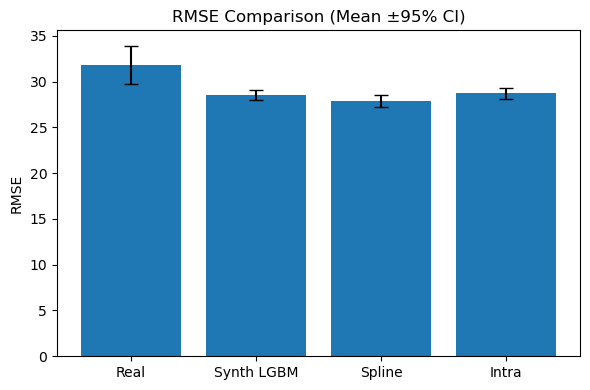

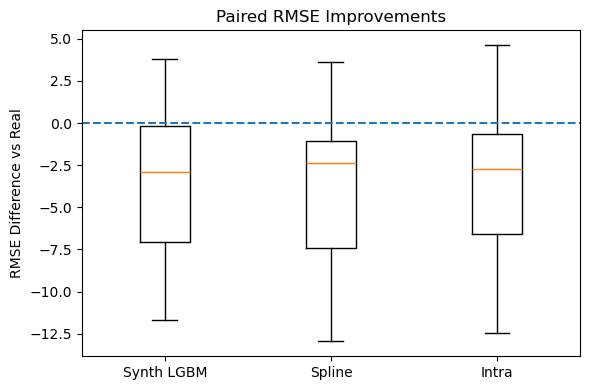

In [57]:
df_rmse = evaluate_metric("rmse")


===== MAE RESULTS =====


,method,mae_mean,diff_mean,ci_low,ci_high,p_value,effect_size_d,p_corrected,significant,improvement_%
0,Synth LGBM,20.7600,-1.8747,-3.4748,-0.2746,2.45e-02,-0.602,4.89e-02,True,8.28
1,Spline,20.3406,-2.2941,-3.9495,-0.6386,9.65e-03,-0.713,2.90e-02,True,10.14
2,Intra,20.8987,-1.7360,-3.4639,-0.0082,4.90e-02,-0.517,4.90e-02,True,7.67


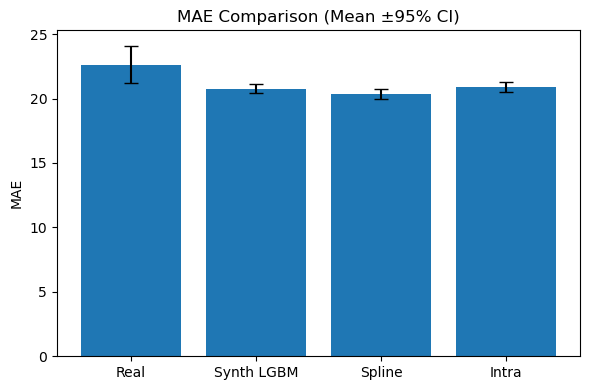

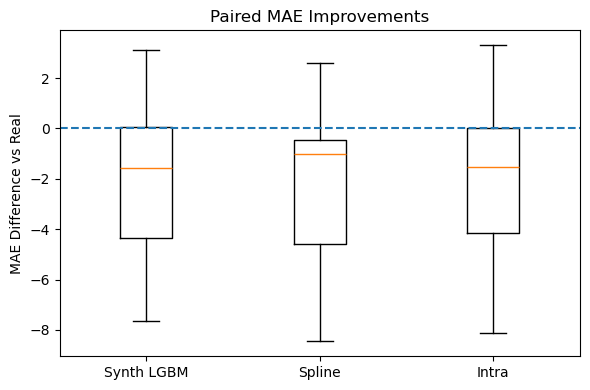

In [58]:
df_mae = evaluate_metric("mae")

### SHAP


In [12]:
all_days = np.array(sorted(synt_ds_lgbm["day"].unique()))
final_test_days = all_days[-FINAL_TEST_DAYS:]
FEATURE_COLS = features()
all_data_set = synt_ds_lgbm
tune_days = all_days[:-FINAL_TEST_DAYS]
params = {
                "depth" : 8,
                "iterations" : 466,
                "l2_leaf_reg" : 7,
                "learning_rate" : 0.0037939942586463823,
                "objective": "RMSE",
                "random_state": 42,
                "silent" : True,
                "task_type" : "GPU",
                "boosting_type":'Plain',
                'synth_weight': 0.6498855231068016,
            }

# Best overall params: {'synth_weight': 0.6498855231068016, 'retrain_every': 8, 'depth': 8, 'learning_rate': 0.0037939942586463823, 'iterations': 466, 'l2_leaf_reg': 7}

C:\Users\local_user\AppData\Local\Temp\ipykernel_9644\1800416222.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


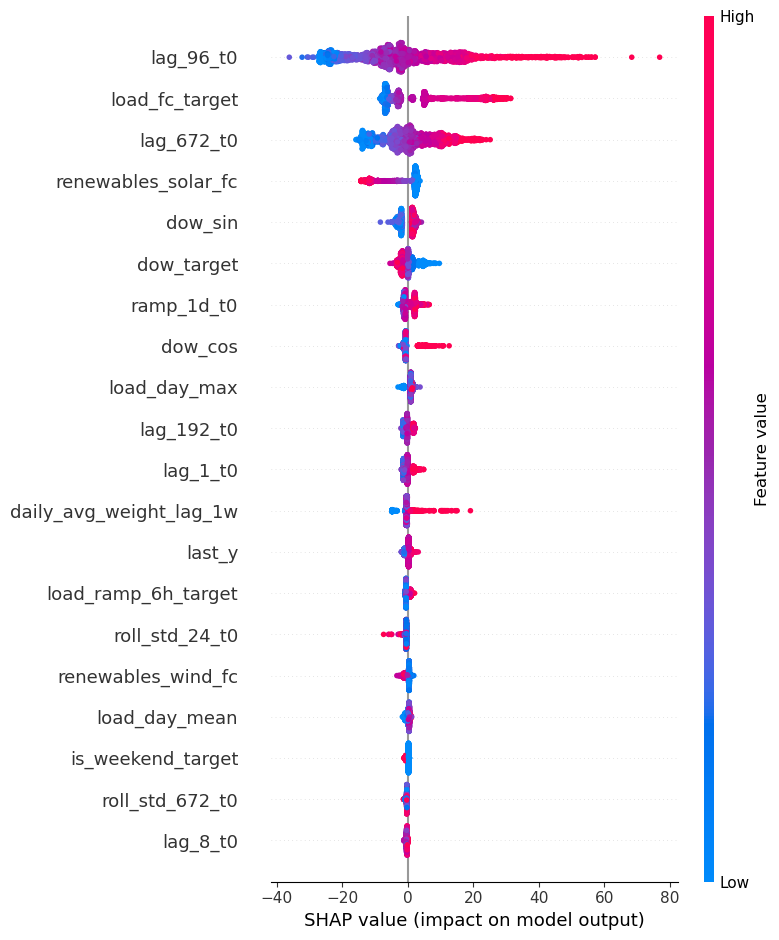

C:\Users\local_user\AppData\Local\Temp\ipykernel_9644\1800416222.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


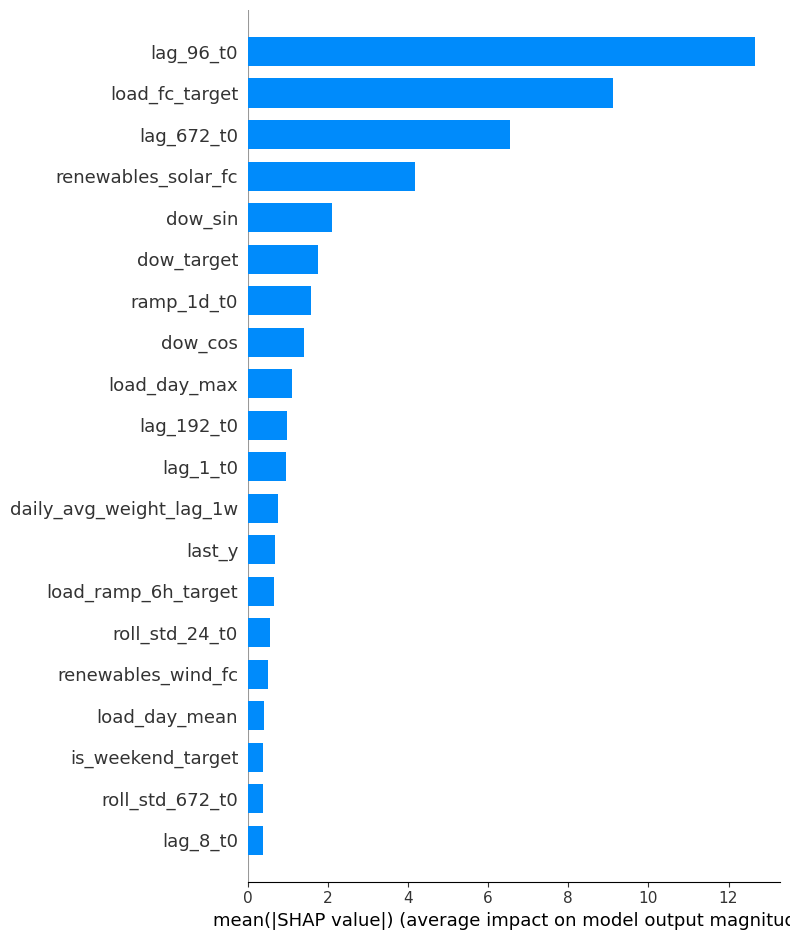

In [13]:
first_test_day = final_test_days[0]

final_model = fit_final_model_before_test(
    ds=all_data_set,
    best_params=params,
    train_days_pool=tune_days,
    first_test_day=first_test_day,
    feature_cols=FEATURE_COLS,
)

test_df = all_data_set[all_data_set["day"].isin(final_test_days)].copy()
X_test = test_df[FEATURE_COLS]


explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Summary plot (beeswarm)
shap.summary_plot(shap_values, X_test)

# Bar plot (global importance)
shap.summary_plot(shap_values, X_test, plot_type="bar")